# Diseño de controladores de parámetros

Este notebook muestra cómo usar la función `asigne_polos` para diseñar un controlador de dos parámetros de la siguiente forma:


In [ ]:
!pip install control
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl

#!wget -O metodo_algebraico.py https://raw.githubusercontent.com/nebisman/control-material/refs/heads/main/notebooks/metodo_algebraico.py
from metodo_algebraico import  calcular_itae, dise_2p, asigne_polos

%matplotlib inline
plt.rcParams.update({
    'figure.figsize': (10, 4),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
    'font.size': 11,
})


## 1. Definimos la planta



$$G(s) = \frac{10}{s(s+2)} = \frac{10}{s^2+2s}$$



In [ ]:
G = ctrl.tf([10], [1, 2 , 0])
print("Planta G(s):")
print(G)



## 2. Elegir la función de lazo cerrado deseada

Ahora elegimos una función de lazo cerrado ITAE para cumplir, en lo posible, los requerimientos: 

- $$u(t) \leq 10\,V$$
- $$t_{ee} \leq 1s$$

In [ ]:
T = calcular_itae(orden=2,omega=2.23)
ref = 10
t, y = ctrl.step_response(ref * T)
tu, yu = ctrl.step_response(ref * T / G)  

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(t, y)
ax1.set_title('Respuesta al escalón de T')
ax1.set_xlabel('Tiempo (s)')
ax1.set_ylabel('Amplitud')
ax1.grid(True)

ax2.plot(tu, yu, 'r')
ax2.set_title('Señal de control')
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('Amplitud')
ax2.grid(True)

print(T)

## 3. Diseñar el controlador

Vamos a seleccionar un controlador con una variable libre
$$ {\text{grado } {\bar{D}_H(s)}=2n-1+v_l- \text{grado } D_H(s)} $$
$$\text{grado }  \bar{D}_H(s)=2\times 2-1+1 - 2 =2 $$

In [ ]:
s=ctrl.tf("s")
polos_DH = [-3, -4]
C2p, Tcl, Gur = dise_2p(G,T, polos_DH)

print("=== Controlador de dos parámetros ===\n")
print("Controlador")
print(C2p)
print("\nFunción de lazo cerrado Tcl:")
print(Tcl)

## 4. Respuesta al escalón

Obtenemos la respuesta en lazo cerrado del sistema.


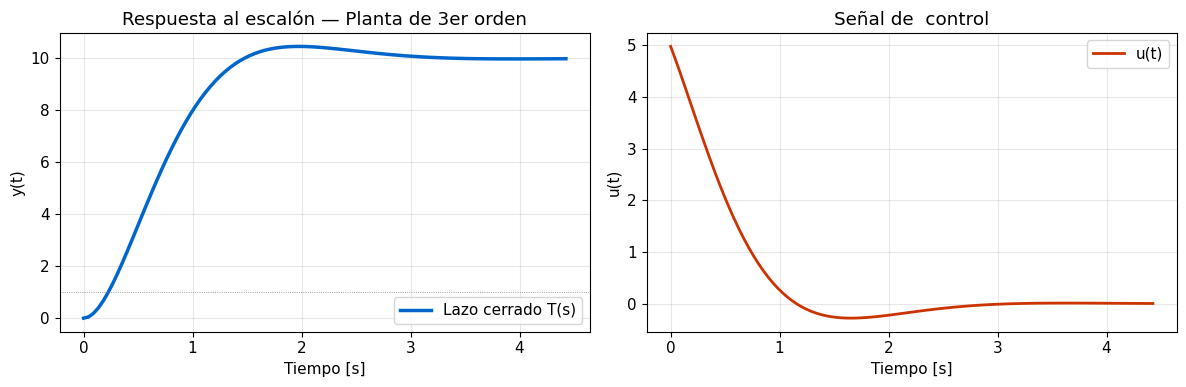

In [61]:
# respuesta al escalón
ref = 10
t_cl, y_cl = ctrl.step_response(ref*T)



fig, axes = plt.subplots(1, 2, figsize=(12, 4))
t_u, y_u = ctrl.step_response(ref*Gur, t_cl)

ax = axes[0]
ax.plot(t_cl, y_cl, "-",  color="#0066cc", lw=2.5, label="Lazo cerrado T(s)")
ax.axhline(1, color="gray", lw=0.6, ls=":")
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("y(t)")
ax.set_title("Respuesta al escalón — Planta de 3er orden")
ax.legend()

ax = axes[1]
ax.plot(t_u, y_u, "-", color="#cc3300", lw=2, label="u(t)")
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("u(t)")
ax.set_title("Señal de  control")
ax.legend()
plt.tight_layout()
plt.show()


# Actividad
 El levitador neumático del laboratorio tiene la siguiente función de transferencia:

 $$G(s)=\frac{48.54}{s^3+14.85s^2+48.54s}$$

 La máxima señal de control que se puede aplicar en valor absoluto es:

 $$|u(t)|\leq 6V$$


 + Diseñe un controlador de dos parámetros de mínimo orden, usando una función de lazo cerrado ITAE que satisgaga la señal de control.
 + Diseñe ahora un controlador de dos parámetros con acción integral
 + Compare alguno de los diseños anteriores con un controlador de realimentación unitaria, sintetizado usando la funcion "asigne_polos". Puede usar help(asigne_polos) para ver la ayuda.